# XGBoost Analysis For GMS Prediction (Time-Binned Dataset)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/time_binned_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (87649, 58)


,datetime,bz_gsm_nt_mean,bz_gsm_nt_min,bz_gsm_nt_max,bz_gsm_nt_last,bz_gsm_nt_trend,b_magnitude_avg_nt_mean,b_magnitude_avg_nt_min,b_magnitude_avg_nt_max,b_magnitude_avg_nt_last,...,ap_27d_ago,speed_27d_ago,ap_target_3h,storm_3h,ap_target_6h,storm_6h,ap_target_12h,storm_12h,ap_target_24h,storm_24h
0,1995-01-01 00:00:00,NaN,NaN,NaN,-0.633333,NaN,NaN,NaN,NaN,3.400000,...,NaN,NaN,0.0,0,3.0,0,2.0,0,5.0,0
1,1995-01-01 03:00:00,NaN,NaN,NaN,0.533333,NaN,NaN,NaN,NaN,4.533333,...,NaN,NaN,3.0,0,5.0,0,4.0,0,9.0,0
2,1995-01-01 06:00:00,NaN,NaN,NaN,0.500000,NaN,NaN,NaN,NaN,4.300000,...,NaN,NaN,5.0,0,2.0,0,12.0,0,12.0,0
3,1995-01-01 09:00:00,-0.366667,-1.866667,0.533333,-1.866667,NaN,4.158333,3.4,4.533333,4.400000,...,NaN,NaN,2.0,0,4.0,0,3.0,0,18.0,0
4,1995-01-01 12:00:00,-0.060000,-1.866667,1.166667,1.166667,NaN,4.013333,3.4,4.533333,3.433333,...,NaN,NaN,4.0,0,12.0,0,5.0,0,9.0,0


In [2]:
df.columns.tolist()

['datetime',
 'bz_gsm_nt_mean',
 'bz_gsm_nt_min',
 'bz_gsm_nt_max',
 'bz_gsm_nt_last',
 'bz_gsm_nt_trend',
 'b_magnitude_avg_nt_mean',
 'b_magnitude_avg_nt_min',
 'b_magnitude_avg_nt_max',
 'b_magnitude_avg_nt_last',
 'b_magnitude_avg_nt_trend',
 'flow_speed_kms_mean',
 'flow_speed_kms_min',
 'flow_speed_kms_max',
 'flow_speed_kms_last',
 'flow_speed_kms_trend',
 'proton_density_cm3_mean',
 'proton_density_cm3_min',
 'proton_density_cm3_max',
 'proton_density_cm3_last',
 'proton_density_cm3_trend',
 'flow_pressure_npa_mean',
 'flow_pressure_npa_min',
 'flow_pressure_npa_max',
 'flow_pressure_npa_last',
 'flow_pressure_npa_trend',
 'electric_field_mvpm_mean',
 'electric_field_mvpm_min',
 'electric_field_mvpm_max',
 'electric_field_mvpm_last',
 'electric_field_mvpm_trend',
 'bz_south_mean',
 'bz_south_max',
 'bz_south_last',
 'coupling_mean',
 'coupling_max',
 'flare_count_win',
 'flare_max_class_now',
 'cme_count_72h',
 'cme_earthdir_count_72h',
 'cme_max_speed_72h',
 'cme_max_half_angl

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 87649 entries, 0 to 87648
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   datetime                   87649 non-null  str    
 1   bz_gsm_nt_mean             87609 non-null  float64
 2   bz_gsm_nt_min              87609 non-null  float64
 3   bz_gsm_nt_max              87609 non-null  float64
 4   bz_gsm_nt_last             87586 non-null  float64
 5   bz_gsm_nt_trend            87527 non-null  float64
 6   b_magnitude_avg_nt_mean    87609 non-null  float64
 7   b_magnitude_avg_nt_min     87609 non-null  float64
 8   b_magnitude_avg_nt_max     87609 non-null  float64
 9   b_magnitude_avg_nt_last    87588 non-null  float64
 10  b_magnitude_avg_nt_trend   87531 non-null  float64
 11  flow_speed_kms_mean        87596 non-null  float64
 12  flow_speed_kms_min         87596 non-null  float64
 13  flow_speed_kms_max         87596 non-null  float64
 14  f

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
datetime,87649,87649,1995-01-01 00:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bz_gsm_nt_mean,87609.0,NaN,NaN,NaN,-0.062075,1.656134,-16.4125,-0.833333,-0.075,0.7,13.958333
bz_gsm_nt_min,87609.0,NaN,NaN,NaN,-2.622715,2.639565,-48.466667,-3.4,-2.1,-1.133333,7.966667
bz_gsm_nt_max,87609.0,NaN,NaN,NaN,2.48699,2.515971,-12.933333,1.0,1.966667,3.3,35.133333
bz_gsm_nt_last,87586.0,NaN,NaN,NaN,-0.062089,2.647114,-48.466667,-1.3,-0.066667,1.166667,35.133333
bz_gsm_nt_trend,87527.0,NaN,NaN,NaN,0.000771,3.620468,-50.566667,-1.666667,0.0,1.6,47.933333
b_magnitude_avg_nt_mean,87609.0,NaN,NaN,NaN,5.771595,2.545877,1.191667,4.05,5.245833,6.845833,34.725
b_magnitude_avg_nt_min,87609.0,NaN,NaN,NaN,4.27178,1.799083,0.6,3.0,3.966667,5.166667,23.7
b_magnitude_avg_nt_max,87609.0,NaN,NaN,NaN,7.586044,4.025046,1.466667,5.033333,6.566667,8.966667,56.666667
b_magnitude_avg_nt_last,87588.0,NaN,NaN,NaN,5.771794,2.992078,0.6,3.866667,5.1,6.833333,56.666667


In [5]:
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["datetime"].min(), "to", df["datetime"].max())

df[["datetime", "ap_now", "ap_target_3h", "storm_3h", "ap_target_6h", "storm_6h"]].head()

Shape: (87649, 58)
Date range: 1995-01-01 00:00:00 to 2024-12-30 00:00:00


,datetime,ap_now,ap_target_3h,storm_3h,ap_target_6h,storm_6h
0,1995-01-01 00:00:00,4.0,0.0,0,3.0,0
1,1995-01-01 03:00:00,0.0,3.0,0,5.0,0
2,1995-01-01 06:00:00,3.0,5.0,0,2.0,0
3,1995-01-01 09:00:00,5.0,2.0,0,4.0,0
4,1995-01-01 12:00:00,2.0,4.0,0,12.0,0


In [6]:
target_cols = ["storm_3h", "storm_6h", "storm_12h", "storm_24h"]

for col in target_cols:
    print(f"\n{col}")
    print(df[col].value_counts())
    print("Storm rate:", round(df[col].mean() * 100, 2), "%")


storm_3h
storm_3h
0    86043
1     1606
Name: count, dtype: int64
Storm rate: 1.83 %

storm_6h
storm_6h
0    86043
1     1606
Name: count, dtype: int64
Storm rate: 1.83 %

storm_12h
storm_12h
0    86043
1     1606
Name: count, dtype: int64
Storm rate: 1.83 %

storm_24h
storm_24h
0    86043
1     1606
Name: count, dtype: int64
Storm rate: 1.83 %


In [7]:
df[["storm_3h", "storm_6h", "storm_12h", "storm_24h"]].drop_duplicates().head(10)

,storm_3h,storm_6h,storm_12h,storm_24h
0,0,0,0,0
8,0,0,0,1
12,0,0,1,0
14,0,1,0,0
15,1,0,0,0
130,0,0,1,1
132,0,1,1,0
133,1,1,1,0
135,1,1,0,0
340,0,1,1,1


In [8]:
(df["storm_3h"] == df["storm_6h"]).mean(), (df["storm_3h"] == df["storm_12h"]).mean(), (df["storm_3h"] == df["storm_24h"]).mean()

(np.float64(0.9818822804595603),
 np.float64(0.9733254229939874),
 np.float64(0.9676208513502721))

In [9]:
# Check whether future Ap targets match shifted ap_now values
for hours in [3, 6, 12, 24]:
    steps = hours // 3
    target_col = f"ap_target_{hours}h"
    
    comparison = np.isclose(
        df[target_col].iloc[:-steps],
        df["ap_now"].shift(-steps).iloc[:-steps],
        equal_nan=True
    )
    
    print(f"{target_col} matches ap_now shifted by {steps} row(s):", comparison.mean())

ap_target_3h matches ap_now shifted by 1 row(s): 1.0
ap_target_6h matches ap_now shifted by 2 row(s): 1.0
ap_target_12h matches ap_now shifted by 4 row(s): 1.0
ap_target_24h matches ap_now shifted by 8 row(s): 1.0


In [10]:
for threshold in [27, 32, 39, 50, 56, 67, 100]:
    print(f"\nThreshold: ap > {threshold}")
    for hours in [3, 6, 12, 24]:
        target_col = f"ap_target_{hours}h"
        storm_col = f"storm_{hours}h"
        match_rate = (df[storm_col] == (df[target_col] > threshold).astype(int)).mean()
        print(f"{storm_col}: match rate = {match_rate:.4f}")


Threshold: ap > 27
storm_3h: match rate = 0.9623
storm_6h: match rate = 0.9623
storm_12h: match rate = 0.9623
storm_24h: match rate = 0.9623

Threshold: ap > 32
storm_3h: match rate = 0.9790
storm_6h: match rate = 0.9790
storm_12h: match rate = 0.9790
storm_24h: match rate = 0.9790

Threshold: ap > 39
storm_3h: match rate = 0.9918
storm_6h: match rate = 0.9918
storm_12h: match rate = 0.9918
storm_24h: match rate = 0.9918

Threshold: ap > 50
storm_3h: match rate = 1.0000
storm_6h: match rate = 1.0000
storm_12h: match rate = 1.0000
storm_24h: match rate = 1.0000

Threshold: ap > 56
storm_3h: match rate = 0.9943
storm_6h: match rate = 0.9943
storm_12h: match rate = 0.9943
storm_24h: match rate = 0.9943

Threshold: ap > 67
storm_3h: match rate = 0.9902
storm_6h: match rate = 0.9902
storm_12h: match rate = 0.9902
storm_24h: match rate = 0.9902

Threshold: ap > 100
storm_3h: match rate = 0.9858
storm_6h: match rate = 0.9858
storm_12h: match rate = 0.9858
storm_24h: match rate = 0.9858


In [11]:
df_2010 = df[df["datetime"] >= "2010-01-01"].copy()

print("Full dataset shape:", df.shape)
print("Full date range:", df["datetime"].min(), "to", df["datetime"].max())

print("\n2010 onward shape:", df_2010.shape)
print("2010 onward date range:", df_2010["datetime"].min(), "to", df_2010["datetime"].max())

print("\nStorm rate full:", round(df["storm_3h"].mean() * 100, 2), "%")
print("Storm rate 2010 onward:", round(df_2010["storm_3h"].mean() * 100, 2), "%")

Full dataset shape: (87649, 58)
Full date range: 1995-01-01 00:00:00 to 2024-12-30 00:00:00

2010 onward shape: (43817, 58)
2010 onward date range: 2010-01-01 00:00:00 to 2024-12-30 00:00:00

Storm rate full: 1.83 %
Storm rate 2010 onward: 1.26 %


In [12]:
missing_2010 = df_2010.isna().sum().sort_values(ascending=False)
missing_2010[missing_2010 > 0].head(15)

flare_count_win              20769
flare_max_class_now          20769
cme_max_speed_now              740
cme_count_24h                  740
cme_max_half_angle_72h         740
cme_max_speed_72h              740
cme_earthdir_count_72h         740
cme_count_72h                  740
proton_density_cm3_trend       179
flow_pressure_npa_trend        179
flow_pressure_npa_last          96
proton_density_cm3_last         96
electric_field_mvpm_trend       74
flow_speed_kms_trend            68
bz_gsm_nt_trend                 46
dtype: int64

Although the full time-binned dataset spans 1995–2024, this notebook uses the 2010 onward subset because the dataset quality check confirmed that the 3-hour grid is fully regular over 2010–2024. This subset also matches the finalized modeling dataset described by the team, with 43,817 rows and a storm rate of about 1.26%.

1. XGBClassifier: predict storm_3h
2. XGBRegressor: predict ap_target_3h

- time-aware train/test split
- storm class imbalance handling
- compare against persistence baseline
- start with 3h horizon first

In [13]:
df_model = df[df["datetime"] >= "2010-01-01"].copy()

print("Shape:", df_model.shape)
print("Date range:", df_model["datetime"].min(), "to", df_model["datetime"].max())

Shape: (43817, 58)
Date range: 2010-01-01 00:00:00 to 2024-12-30 00:00:00


In [14]:
# making XGBoost feature set
TARGET_CLASS = "storm_3h"
TARGET_REG = "ap_target_3h"

In [15]:
target_cols = [
    "ap_target_3h", "storm_3h",
    "ap_target_6h", "storm_6h",
    "ap_target_12h", "storm_12h",
    "ap_target_24h", "storm_24h",
]

non_feature_cols = ["datetime"] + target_cols

FEATURE_COLS = [col for col in df_model.columns if col not in non_feature_cols]

print("Number of features:", len(FEATURE_COLS))
FEATURE_COLS

Number of features: 49


['bz_gsm_nt_mean',
 'bz_gsm_nt_min',
 'bz_gsm_nt_max',
 'bz_gsm_nt_last',
 'bz_gsm_nt_trend',
 'b_magnitude_avg_nt_mean',
 'b_magnitude_avg_nt_min',
 'b_magnitude_avg_nt_max',
 'b_magnitude_avg_nt_last',
 'b_magnitude_avg_nt_trend',
 'flow_speed_kms_mean',
 'flow_speed_kms_min',
 'flow_speed_kms_max',
 'flow_speed_kms_last',
 'flow_speed_kms_trend',
 'proton_density_cm3_mean',
 'proton_density_cm3_min',
 'proton_density_cm3_max',
 'proton_density_cm3_last',
 'proton_density_cm3_trend',
 'flow_pressure_npa_mean',
 'flow_pressure_npa_min',
 'flow_pressure_npa_max',
 'flow_pressure_npa_last',
 'flow_pressure_npa_trend',
 'electric_field_mvpm_mean',
 'electric_field_mvpm_min',
 'electric_field_mvpm_max',
 'electric_field_mvpm_last',
 'electric_field_mvpm_trend',
 'bz_south_mean',
 'bz_south_max',
 'bz_south_last',
 'coupling_mean',
 'coupling_max',
 'flare_count_win',
 'flare_max_class_now',
 'cme_count_72h',
 'cme_earthdir_count_72h',
 'cme_max_speed_72h',
 'cme_max_half_angle_72h',
 'cme

In [16]:
# time-based train/test split 
TARGET_CLASS = "storm_3h"
TARGET_REG = "ap_target_3h"

split_date = "2022-01-01"

train_df = df_model[df_model["datetime"] < split_date].copy()
test_df = df_model[df_model["datetime"] >= split_date].copy()

X_train = train_df[FEATURE_COLS]
X_test = test_df[FEATURE_COLS]

y_train_class = train_df[TARGET_CLASS]
y_test_class = test_df[TARGET_CLASS]

y_train_reg = train_df[TARGET_REG]
y_test_reg = test_df[TARGET_REG]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain date range:", train_df["datetime"].min(), "to", train_df["datetime"].max())
print("Test date range:", test_df["datetime"].min(), "to", test_df["datetime"].max())

print("\nClassification target balance:")
print("Train:")
print(y_train_class.value_counts())
print("Train storm rate:", round(y_train_class.mean() * 100, 2), "%")

print("\nTest:")
print(y_test_class.value_counts())
print("Test storm rate:", round(y_test_class.mean() * 100, 2), "%")

Train shape: (35064, 49)
Test shape: (8753, 49)

Train date range: 2010-01-01 00:00:00 to 2021-12-31 21:00:00
Test date range: 2022-01-01 00:00:00 to 2024-12-30 00:00:00

Classification target balance:
Train:
storm_3h
0    34685
1      379
Name: count, dtype: int64
Train storm rate: 1.08 %

Test:
storm_3h
0    8579
1     174
Name: count, dtype: int64
Test storm rate: 1.99 %


### 1) XGBoost regression

In [17]:
# persistence baseline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Persistence baseline for 3-hour ahead Ap prediction
y_pred_persistence = test_df["ap_now"]

mae_persistence = mean_absolute_error(y_test_reg, y_pred_persistence)
rmse_persistence = mean_squared_error(y_test_reg, y_pred_persistence) ** 0.5
r2_persistence = r2_score(y_test_reg, y_pred_persistence)

print("Persistence Baseline — 3h Ap Prediction")
print(f"MAE : {mae_persistence:.3f}")
print(f"RMSE: {rmse_persistence:.3f}")
print(f"R²  : {r2_persistence:.3f}")

Persistence Baseline — 3h Ap Prediction
MAE : 5.256
RMSE: 11.253
R²  : 0.603


In [18]:
# XGBoost regression for ap_target_3h
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

xgb_reg_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1
    ))
])

xgb_reg_pipe.fit(X_train, y_train_reg)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](49,)","['bz_gsm_nt_mean','bz_gsm_nt_min','bz_gsm_nt_max',...,'ap_trend', 'ap_27d_ago','speed_27d_ago']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,49
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or

In [19]:
y_pred_xgb_reg = xgb_reg_pipe.predict(X_test)

mae_xgb = mean_absolute_error(y_test_reg, y_pred_xgb_reg)
rmse_xgb = mean_squared_error(y_test_reg, y_pred_xgb_reg) ** 0.5
r2_xgb = r2_score(y_test_reg, y_pred_xgb_reg)

print("XGBoost Regression — 3h Ap Prediction")
print(f"MAE : {mae_xgb:.3f}")
print(f"RMSE: {rmse_xgb:.3f}")
print(f"R²  : {r2_xgb:.3f}")

print("\nPersistence Baseline")
print(f"MAE : {mae_persistence:.3f}")
print(f"RMSE: {rmse_persistence:.3f}")
print(f"R²  : {r2_persistence:.3f}")

XGBoost Regression — 3h Ap Prediction
MAE : 5.032
RMSE: 12.274
R²  : 0.528

Persistence Baseline
MAE : 5.256
RMSE: 11.253
R²  : 0.603


### XGBoost Regression Results

The XGBoost regression model slightly improved MAE compared with the persistence baseline, but it performed worse on RMSE and R². This suggests that the model may predict common quiet-time Ap values reasonably well, but it struggles with larger Ap spikes and storm-level events. Since RMSE penalizes large errors more heavily than MAE, the worse RMSE indicates that the model is likely missing some extreme geomagnetic activity periods.

Overall, the initial XGBoost regression baseline did not clearly outperform persistence for 3-hour Ap forecasting. This shows that persistence is a strong baseline at short forecast horizons and that future work should focus on handling rare high-Ap events better, such as using target transformations, weighted losses, or storm-focused classification.

In [20]:
results_reg = test_df[["datetime", "ap_now", "ap_target_3h", "storm_3h"]].copy()
results_reg["xgb_pred_ap_3h"] = y_pred_xgb_reg
results_reg["persistence_pred_ap_3h"] = y_pred_persistence

results_reg["xgb_abs_error"] = (results_reg["ap_target_3h"] - results_reg["xgb_pred_ap_3h"]).abs()
results_reg["persistence_abs_error"] = (results_reg["ap_target_3h"] - results_reg["persistence_pred_ap_3h"]).abs()

print("Mean absolute error by actual storm label:")
print(
    results_reg.groupby("storm_3h")[["xgb_abs_error", "persistence_abs_error"]].mean()
)

Mean absolute error by actual storm label:
          xgb_abs_error  persistence_abs_error
storm_3h                                      
0              4.097793               4.459028
1             51.082778              44.545977


### Error Analysis by Storm Label

The XGBoost regression model performed better than the persistence baseline during non-storm periods, with lower mean absolute error for quiet-time bins. However, it performed worse during actual storm periods. For storm bins, XGBoost had a higher mean absolute error than persistence, suggesting that the model struggled to predict rare high-Ap spikes.

This explains why XGBoost slightly improved overall MAE but performed worse on RMSE and R². The model appears to fit the quiet majority better, but it does not yet capture extreme geomagnetic activity well enough. Since storm events are the most important cases for this project, future work should focus on storm-weighted training, target transformations, or classification models that explicitly prioritize rare storm events.

### 2) XGBoost classification

In [21]:
# XGBoost Classification
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)
from xgboost import XGBClassifier

negative_count = (y_train_class == 0).sum()
positive_count = (y_train_class == 1).sum()
scale_pos_weight = negative_count / positive_count

print("scale_pos_weight:", round(scale_pos_weight, 2))

scale_pos_weight: 91.52


In [22]:
xgb_clf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

xgb_clf_pipe.fit(X_train, y_train_class)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](49,)","['bz_gsm_nt_mean','bz_gsm_nt_min','bz_gsm_nt_max',...,'ap_trend', 'ap_27d_ago','speed_27d_ago']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,49
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. F

In [23]:
y_pred_class = xgb_clf_pipe.predict(X_test)
y_pred_prob = xgb_clf_pipe.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test_class, y_pred_prob)
pr_auc = average_precision_score(y_test_class, y_pred_prob)

print("XGBoost Classification — 3h Storm Prediction")
print(f"ROC-AUC : {roc_auc:.3f}")
print(f"PR-AUC  : {pr_auc:.3f}  (no-skill baseline = {y_test_class.mean():.3f})")
print()
print(classification_report(y_test_class, y_pred_class, target_names=["No storm", "Storm"]))

print("Confusion matrix:")
print(confusion_matrix(y_test_class, y_pred_class))

XGBoost Classification — 3h Storm Prediction
ROC-AUC : 0.965
PR-AUC  : 0.576  (no-skill baseline = 0.020)

              precision    recall  f1-score   support

    No storm       1.00      0.94      0.97      8579
       Storm       0.22      0.86      0.35       174

    accuracy                           0.94      8753
   macro avg       0.61      0.90      0.66      8753
weighted avg       0.98      0.94      0.95      8753

Confusion matrix:
[[8046  533]
 [  24  150]]


### XGBoost Classification Results

The XGBoost classification model performed much better than the earlier event-level models on the time-binned dataset. For 3-hour-ahead storm prediction, the model achieved a ROC-AUC of 0.965 and a PR-AUC of 0.576, which is far above the no-skill baseline of 0.020. This suggests that the time-binned features contain meaningful predictive signal for identifying storm conditions.

At the default threshold, the model caught 150 out of 174 storm bins, giving a storm recall of 0.86. However, storm precision was 0.22, meaning the model also produced many false alarms. This tradeoff may still be useful for an early-warning setting, where missing storms can be more costly than issuing extra warnings.

In [24]:
# Top features used by the XGBoost classifier
importances = pd.Series(
    xgb_clf_pipe.named_steps["model"].feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

importances.head(15)

ap_now                      0.249516
ap_trend                    0.086352
b_magnitude_avg_nt_last     0.054114
ap_max                      0.044077
ap_mean                     0.030116
flow_pressure_npa_last      0.027888
cme_max_half_angle_72h      0.022770
b_magnitude_avg_nt_trend    0.022035
flow_pressure_npa_max       0.020041
cme_max_speed_72h           0.019596
electric_field_mvpm_last    0.018363
flow_pressure_npa_trend     0.018029
bz_gsm_nt_min               0.015311
bz_south_max                0.015291
bz_gsm_nt_last              0.014267
dtype: float32

In [25]:
# with stricter feature set excluding current/recent Ap features
AP_FEATURES_TO_REMOVE = ["ap_now", "ap_mean", "ap_max", "ap_trend"]

FEATURE_COLS_NO_AP = [col for col in FEATURE_COLS if col not in AP_FEATURES_TO_REMOVE]

print("Original feature count:", len(FEATURE_COLS))
print("No-current-Ap feature count:", len(FEATURE_COLS_NO_AP))
FEATURE_COLS_NO_AP

Original feature count: 49
No-current-Ap feature count: 45


['bz_gsm_nt_mean',
 'bz_gsm_nt_min',
 'bz_gsm_nt_max',
 'bz_gsm_nt_last',
 'bz_gsm_nt_trend',
 'b_magnitude_avg_nt_mean',
 'b_magnitude_avg_nt_min',
 'b_magnitude_avg_nt_max',
 'b_magnitude_avg_nt_last',
 'b_magnitude_avg_nt_trend',
 'flow_speed_kms_mean',
 'flow_speed_kms_min',
 'flow_speed_kms_max',
 'flow_speed_kms_last',
 'flow_speed_kms_trend',
 'proton_density_cm3_mean',
 'proton_density_cm3_min',
 'proton_density_cm3_max',
 'proton_density_cm3_last',
 'proton_density_cm3_trend',
 'flow_pressure_npa_mean',
 'flow_pressure_npa_min',
 'flow_pressure_npa_max',
 'flow_pressure_npa_last',
 'flow_pressure_npa_trend',
 'electric_field_mvpm_mean',
 'electric_field_mvpm_min',
 'electric_field_mvpm_max',
 'electric_field_mvpm_last',
 'electric_field_mvpm_trend',
 'bz_south_mean',
 'bz_south_max',
 'bz_south_last',
 'coupling_mean',
 'coupling_max',
 'flare_count_win',
 'flare_max_class_now',
 'cme_count_72h',
 'cme_earthdir_count_72h',
 'cme_max_speed_72h',
 'cme_max_half_angle_72h',
 'cme

In [26]:
X_train_no_ap = train_df[FEATURE_COLS_NO_AP]
X_test_no_ap = test_df[FEATURE_COLS_NO_AP]

xgb_clf_no_ap_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

xgb_clf_no_ap_pipe.fit(X_train_no_ap, y_train_class)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](45,)","['bz_gsm_nt_mean','bz_gsm_nt_min','bz_gsm_nt_max',...,'cme_max_speed_now', 'ap_27d_ago','speed_27d_ago']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,45
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_

In [27]:
y_pred_no_ap = xgb_clf_no_ap_pipe.predict(X_test_no_ap)
y_pred_prob_no_ap = xgb_clf_no_ap_pipe.predict_proba(X_test_no_ap)[:, 1]

roc_auc_no_ap = roc_auc_score(y_test_class, y_pred_prob_no_ap)
pr_auc_no_ap = average_precision_score(y_test_class, y_pred_prob_no_ap)

print("XGBoost Classification without Current Ap Features — 3h Storm Prediction")
print(f"ROC-AUC : {roc_auc_no_ap:.3f}")
print(f"PR-AUC  : {pr_auc_no_ap:.3f}  (no-skill baseline = {y_test_class.mean():.3f})")
print()
print(classification_report(y_test_class, y_pred_no_ap, target_names=["No storm", "Storm"]))

print("Confusion matrix:")
print(confusion_matrix(y_test_class, y_pred_no_ap))

XGBoost Classification without Current Ap Features — 3h Storm Prediction
ROC-AUC : 0.953
PR-AUC  : 0.550  (no-skill baseline = 0.020)

              precision    recall  f1-score   support

    No storm       1.00      0.93      0.96      8579
       Storm       0.21      0.84      0.33       174

    accuracy                           0.93      8753
   macro avg       0.60      0.89      0.65      8753
weighted avg       0.98      0.93      0.95      8753

Confusion matrix:
[[8017  562]
 [  28  146]]


With Ap features:
ROC-AUC = 0.965
PR-AUC  = 0.576
Recall  = 0.86
Precision = 0.22

Without current Ap features:
ROC-AUC = 0.953
PR-AUC  = 0.550
Recall  = 0.84
Precision = 0.21

### No-Current-Ap Feature Check

Because the first XGBoost classifier relied heavily on current Ap features, we trained a stricter version of the model after removing `ap_now`, `ap_mean`, `ap_max`, and `ap_trend`. This check helps determine whether the model is only learning short-term geomagnetic persistence or whether solar wind, magnetic field, CME, flare, and recurrence features also contain predictive signal.

The no-current-Ap model still performed strongly, with a ROC-AUC of 0.953 and a PR-AUC of 0.550 compared with a no-skill baseline of 0.020. It caught 146 out of 174 storm bins, giving a storm recall of 0.84. Precision remained low at 0.21, meaning the model produced many false alarms, but this is expected given the severe class imbalance.

Overall, this result suggests that the time-binned non-Ap features contain meaningful predictive signal for 3-hour-ahead storm classification, not just current geomagnetic activity.

### Feature Importance

In [28]:
importances_no_ap = pd.Series(
    xgb_clf_no_ap_pipe.named_steps["model"].feature_importances_,
    index=FEATURE_COLS_NO_AP
).sort_values(ascending=False)

importances_no_ap.head(15)

b_magnitude_avg_nt_last     0.196788
b_magnitude_avg_nt_max      0.121559
coupling_max                0.047388
flow_pressure_npa_max       0.046796
flow_pressure_npa_last      0.045340
electric_field_mvpm_last    0.038026
flow_speed_kms_last         0.035922
bz_gsm_nt_last              0.027809
cme_max_speed_72h           0.023817
coupling_mean               0.023707
cme_earthdir_count_72h      0.023080
flow_pressure_npa_trend     0.022012
electric_field_mvpm_max     0.021555
cme_max_half_angle_72h      0.018240
b_magnitude_avg_nt_mean     0.017243
dtype: float32

### Feature Importance for No-Current-Ap Model

After removing current Ap features, the XGBoost classifier relied most heavily on recent solar wind and magnetic field conditions. The top features included recent IMF magnitude, maximum IMF magnitude, solar wind coupling, dynamic pressure, electric field, wind speed, Bz, and CME activity over the previous 72 hours.

This is encouraging because the model still performed strongly without direct current geomagnetic activity inputs. The feature importance results suggest that the model is learning from physically meaningful upstream solar wind and CME indicators. In particular, `_last` and `_max` features ranked highly, supporting the idea that recent and extreme conditions are more useful than simple averages for short-term storm prediction.

However, XGBoost feature importance does not show whether a feature increases or decreases storm probability. It only shows which features the model used most often or most strongly for prediction, so these results should be interpreted as model behavior rather than causal proof.

### Threshold Table (with no-current-Ap model)

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_prob_no_ap >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test_class, y_pred_threshold),
        "precision_storm": precision_score(y_test_class, y_pred_threshold, zero_division=0),
        "recall_storm": recall_score(y_test_class, y_pred_threshold, zero_division=0),
        "f1_storm": f1_score(y_test_class, y_pred_threshold, zero_division=0),
        "predicted_storm_count": y_pred_threshold.sum()
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,threshold,accuracy,precision_storm,recall_storm,f1_storm,predicted_storm_count
0,0.1,0.815035,0.091115,0.925287,0.165894,1767
1,0.2,0.867703,0.122120,0.913793,0.215447,1302
2,0.3,0.896835,0.148505,0.885057,0.254335,1037
3,0.4,0.916943,0.177363,0.873563,0.294859,857
4,0.5,0.932595,0.206215,0.839080,0.331066,708
5,0.6,0.944705,0.237288,0.804598,0.366492,590
6,0.7,0.955558,0.276507,0.764368,0.406107,481
7,0.8,0.965155,0.327177,0.712644,0.448463,379
8,0.9,0.976694,0.438017,0.609195,0.509615,242


### Threshold Tradeoff

The no-current-Ap XGBoost classifier shows a clear precision-recall tradeoff. At lower thresholds, the model catches more storm events but produces more false alarms. At higher thresholds, precision improves and the number of predicted storm bins decreases, but recall drops.

For example, at the default 0.50 threshold, the model achieved high storm recall of 0.84 but low precision of 0.21. Increasing the threshold to 0.80 improved precision to 0.33 while still keeping recall at 0.71. At 0.90, precision increased further to 0.44, but recall dropped to 0.61.

This suggests that the classification threshold should depend on the use case. For an early-warning system where missing storms is costly, a lower threshold may be preferred. If reducing false alarms is more important, a higher threshold such as 0.80 or 0.90 may be more appropriate.

These results are promising, but they should be interpreted as an initial baseline rather than a final operational model. The no-current-Ap XGBoost classifier suggests that solar wind, magnetic field, CME, and recurrence features contain useful signal for 3-hour-ahead storm prediction. However, precision remains limited due to severe class imbalance, and the threshold choice creates a tradeoff between catching more storms and reducing false alarms.

Future work should test additional forecast horizons, compare against persistence baselines, tune hyperparameters, validate across different time periods, and further investigate whether the model generalizes to rare extreme storm events.

# SUMMARY 

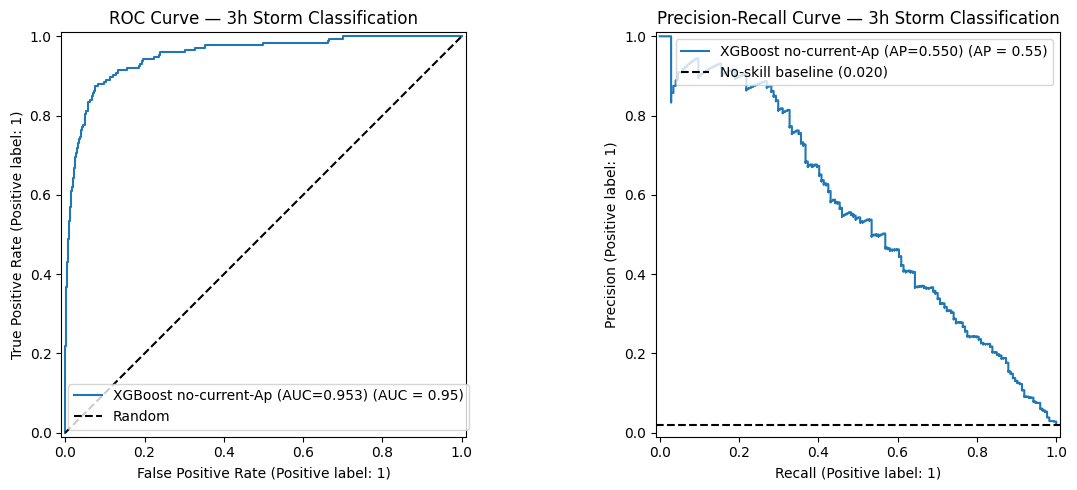

In [30]:
# ROC/PR Curve for no-current-Ap XGBoost classifier
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_test_class,
    y_pred_prob_no_ap,
    name=f"XGBoost no-current-Ap (AUC={roc_auc_no_ap:.3f})",
    ax=axes[0],
)
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_title("ROC Curve — 3h Storm Classification")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y_test_class,
    y_pred_prob_no_ap,
    name=f"XGBoost no-current-Ap (AP={pr_auc_no_ap:.3f})",
    ax=axes[1],
)
axes[1].axhline(
    y_test_class.mean(),
    color="k",
    linestyle="--",
    label=f"No-skill baseline ({y_test_class.mean():.3f})"
)
axes[1].set_title("Precision-Recall Curve — 3h Storm Classification")
axes[1].legend()

plt.tight_layout()
plt.show()

### ROC and Precision-Recall Curves

The no-current-Ap XGBoost classifier showed strong ranking performance for 3-hour-ahead storm prediction. The ROC-AUC was 0.953, indicating that the model generally ranked storm bins above non-storm bins well. The PR-AUC was 0.550, far above the no-skill baseline of 0.020, which is especially important because storm bins are rare.

The precision-recall curve is more informative than accuracy for this task because only about 2% of the test bins are storm events. The curve shows that the model contains useful signal, but threshold selection is still important because higher recall comes with more false alarms.

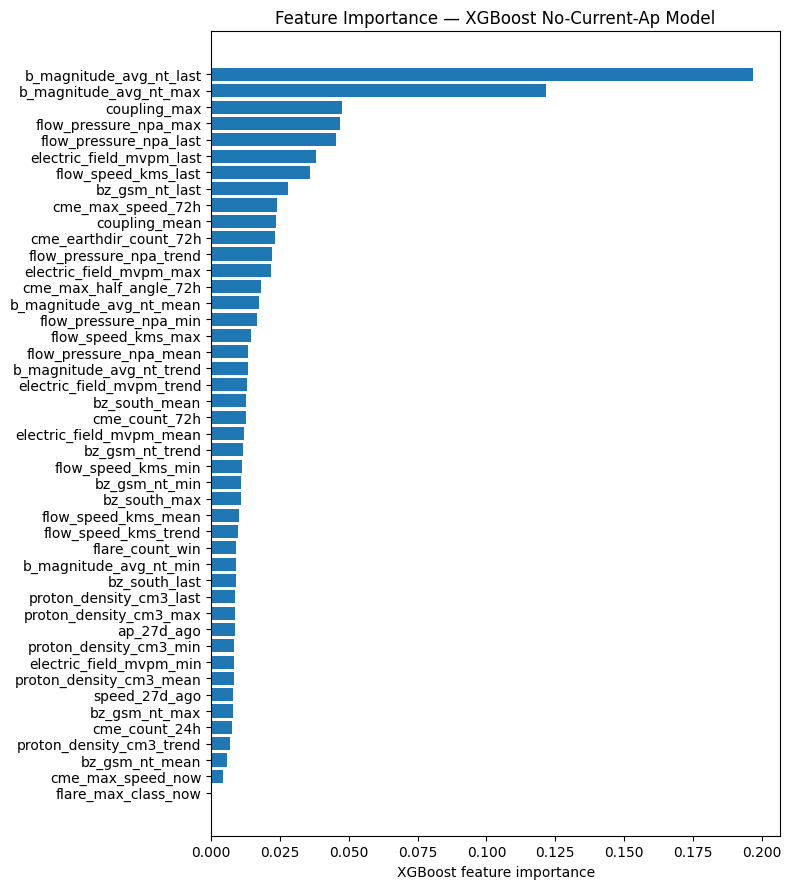


Top features:
b_magnitude_avg_nt_last     0.196788
b_magnitude_avg_nt_max      0.121559
coupling_max                0.047388
flow_pressure_npa_max       0.046796
flow_pressure_npa_last      0.045340
electric_field_mvpm_last    0.038026
flow_speed_kms_last         0.035922
bz_gsm_nt_last              0.027809
cme_max_speed_72h           0.023817
coupling_mean               0.023707
cme_earthdir_count_72h      0.023080
flow_pressure_npa_trend     0.022012
electric_field_mvpm_max     0.021555
cme_max_half_angle_72h      0.018240
b_magnitude_avg_nt_mean     0.017243


In [31]:
# feature importance plot
importances_no_ap = pd.Series(
    xgb_clf_no_ap_pipe.named_steps["model"].feature_importances_,
    index=FEATURE_COLS_NO_AP
).sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(importances_no_ap.index, importances_no_ap.values)
ax.set_xlabel("XGBoost feature importance")
ax.set_title("Feature Importance — XGBoost No-Current-Ap Model")
plt.tight_layout()
plt.show()

print("\nTop features:")
print(importances_no_ap.tail(15).iloc[::-1].to_string())

### Feature Importance

For the no-current-Ap XGBoost model, the most important features were recent solar wind and magnetic field variables, including IMF magnitude, solar wind pressure, electric field, wind speed, Bz, coupling features, and CME activity over the previous 72 hours.

This supports the idea that the model is not relying only on current geomagnetic activity. Instead, it appears to use physically meaningful upstream solar wind and CME indicators for short-term storm classification. However, feature importance does not show causal direction, so these results should be interpreted as model behavior rather than proof that any single feature directly causes storms.

## Initial XGBoost Modeling Summary

This notebook used the 2010–2024 subset of the time-binned dataset, where each row represents a 3-hour time bin. We first evaluated XGBoost regression for 3-hour-ahead Ap prediction and compared it against a persistence baseline. The regression model slightly improved MAE during quiet periods, but it performed worse on storm bins, suggesting that plain regression still struggles with rare high-Ap spikes.

We then evaluated XGBoost classification for 3-hour-ahead storm prediction. The model performed strongly compared with the no-skill baseline, but current Ap features were among the most important predictors. To check whether the model was only learning short-term persistence, we trained a stricter version without current Ap features. This model still achieved strong ROC-AUC and PR-AUC, suggesting that solar wind, magnetic field, CME, and recurrence features contain useful predictive signal.

These results are promising but should be treated as initial baselines rather than final operational conclusions. Future work should test additional forecast horizons, tune thresholds and hyperparameters, compare against persistence at each horizon, and evaluate whether performance generalizes across different time periods and rare extreme storm events.

In [32]:
horizons = [3, 6, 12, 24]

horizon_results = []

for h in horizons:
    target_col = f"storm_{h}h"
    
    y_train_h = train_df[target_col]
    y_test_h = test_df[target_col]
    
    neg_count = (y_train_h == 0).sum()
    pos_count = (y_train_h == 1).sum()
    scale_pos_weight_h = neg_count / pos_count
    
    xgb_horizon_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight_h,
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        ))
    ])
    
    xgb_horizon_pipe.fit(X_train_no_ap, y_train_h)
    
    y_pred_h = xgb_horizon_pipe.predict(X_test_no_ap)
    y_prob_h = xgb_horizon_pipe.predict_proba(X_test_no_ap)[:, 1]
    
    horizon_results.append({
        "horizon": f"{h}h",
        "train_storm_rate": y_train_h.mean(),
        "test_storm_rate": y_test_h.mean(),
        "roc_auc": roc_auc_score(y_test_h, y_prob_h),
        "pr_auc": average_precision_score(y_test_h, y_prob_h),
        "no_skill_pr": y_test_h.mean(),
        "precision": precision_score(y_test_h, y_pred_h, zero_division=0),
        "recall": recall_score(y_test_h, y_pred_h, zero_division=0),
        "f1": f1_score(y_test_h, y_pred_h, zero_division=0),
        "predicted_storm_count": y_pred_h.sum()
    })

horizon_results_df = pd.DataFrame(horizon_results)
horizon_results_df

,horizon,train_storm_rate,test_storm_rate,roc_auc,pr_auc,no_skill_pr,precision,recall,f1,predicted_storm_count
0,3h,0.010809,0.019879,0.953138,0.550322,0.019879,0.206215,0.839080,0.331066,708
1,6h,0.010809,0.019879,0.883937,0.308662,0.019879,0.130011,0.689655,0.218778,923
2,12h,0.010809,0.019879,0.799346,0.152922,0.019879,0.084388,0.574713,0.147167,1185
3,24h,0.010809,0.019879,0.679193,0.036602,0.019879,0.047718,0.264368,0.080844,964


### Forecast Horizon Sweep

To test how prediction difficulty changes with forecast horizon, we trained the no-current-Ap XGBoost classifier for 3-hour, 6-hour, 12-hour, and 24-hour storm prediction. The same time-based train/test split and non-Ap feature set were used for each horizon.

Model performance declined as the forecast horizon increased. The 3-hour model performed strongest, with ROC-AUC of 0.953 and PR-AUC of 0.550 compared with a no-skill PR baseline of 0.020. Performance was still meaningful at 6 hours, but declined further at 12 and 24 hours. By 24 hours, PR-AUC dropped to 0.037 and storm recall dropped to 0.264.

This suggests that the time-binned features are most useful for short-term storm prediction, especially within the next 3 to 6 hours. Longer-horizon forecasting appears more difficult and may require additional feature engineering, event-level context, or different modeling approaches.

## Imbalance Handling

Try oversampling to increase storm examples and see comparisons. Only applying oversampling on training set.

In [33]:
%pip install imbalanced-learn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

Note: you may need to restart the kernel to use updated packages.


In [34]:
xgb_ros_pipe = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("oversampler", RandomOverSampler(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

xgb_ros_pipe.fit(X_train_no_ap, y_train_class)

,steps,"[('imputer', ...), ('oversampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](45,)","['bz_gsm_nt_mean','bz_gsm_nt_min','bz_gsm_nt_max',...,'cme_max_speed_now', 'ap_27d_ago','speed_27d_ago']"
n_features_in_,int,45
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None


In [35]:
y_pred_ros = xgb_ros_pipe.predict(X_test_no_ap)
y_prob_ros = xgb_ros_pipe.predict_proba(X_test_no_ap)[:, 1]

roc_auc_ros = roc_auc_score(y_test_class, y_prob_ros)
pr_auc_ros = average_precision_score(y_test_class, y_prob_ros)

print("XGBoost + Random Oversampling — 3h Storm Prediction")
print(f"ROC-AUC : {roc_auc_ros:.3f}")
print(f"PR-AUC  : {pr_auc_ros:.3f}  (no-skill baseline = {y_test_class.mean():.3f})")
print()
print(classification_report(y_test_class, y_pred_ros, target_names=["No storm", "Storm"]))

print("Confusion matrix:")
print(confusion_matrix(y_test_class, y_pred_ros))

XGBoost + Random Oversampling — 3h Storm Prediction
ROC-AUC : 0.952
PR-AUC  : 0.555  (no-skill baseline = 0.020)

              precision    recall  f1-score   support

    No storm       1.00      0.94      0.97      8579
       Storm       0.21      0.84      0.34       174

    accuracy                           0.93      8753
   macro avg       0.60      0.89      0.65      8753
weighted avg       0.98      0.93      0.95      8753

Confusion matrix:
[[8025  554]
 [  27  147]]


### Random Oversampling Experiment

To address the severe class imbalance in the storm classification task, we tested Random Oversampling on the training set only. This was compared against the previous XGBoost model that used class weighting through `scale_pos_weight`.

Random Oversampling produced very similar results to the weighted XGBoost model. The PR-AUC slightly improved from 0.550 to 0.555, and the model caught 147 out of 174 storm bins compared with 146 for the weighted model. False alarms were also slightly lower. However, the improvement was small, so oversampling should be treated as comparable to class weighting rather than a major breakthrough.

This suggests that the time-binned features contain useful storm-prediction signal, but class imbalance handling alone does not fully solve the false-alarm problem.

In [36]:
# Summary Table

xgb_imbalance_comparison = pd.DataFrame([
    {
        "model": "XGBoost weighted",
        "roc_auc": roc_auc_no_ap,
        "pr_auc": pr_auc_no_ap,
        "precision": precision_score(y_test_class, y_pred_no_ap, zero_division=0),
        "recall": recall_score(y_test_class, y_pred_no_ap, zero_division=0),
        "f1": f1_score(y_test_class, y_pred_no_ap, zero_division=0),
        "predicted_storm_count": y_pred_no_ap.sum()
    },
    {
        "model": "XGBoost random oversampling",
        "roc_auc": roc_auc_ros,
        "pr_auc": pr_auc_ros,
        "precision": precision_score(y_test_class, y_pred_ros, zero_division=0),
        "recall": recall_score(y_test_class, y_pred_ros, zero_division=0),
        "f1": f1_score(y_test_class, y_pred_ros, zero_division=0),
        "predicted_storm_count": y_pred_ros.sum()
    }
])

xgb_imbalance_comparison

,model,roc_auc,pr_auc,precision,recall,f1,predicted_storm_count
0,XGBoost weighted,0.953138,0.550322,0.206215,0.839080,0.331066,708
1,XGBoost random oversampling,0.952124,0.554636,0.209700,0.844828,0.336000,701


In [37]:
# Oversampling model threshold table

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

threshold_results_ros = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_ros >= threshold).astype(int)
    
    threshold_results_ros.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test_class, y_pred_threshold),
        "precision_storm": precision_score(y_test_class, y_pred_threshold, zero_division=0),
        "recall_storm": recall_score(y_test_class, y_pred_threshold, zero_division=0),
        "f1_storm": f1_score(y_test_class, y_pred_threshold, zero_division=0),
        "predicted_storm_count": y_pred_threshold.sum()
    })

threshold_results_ros_df = pd.DataFrame(threshold_results_ros)
threshold_results_ros_df

,threshold,accuracy,precision_storm,recall_storm,f1_storm,predicted_storm_count
0,0.1,0.784874,0.080511,0.942529,0.148349,2037
1,0.2,0.856849,0.113262,0.908046,0.201402,1395
2,0.3,0.893294,0.144195,0.885057,0.247987,1068
3,0.4,0.916829,0.176402,0.867816,0.293204,856
4,0.5,0.933623,0.209700,0.844828,0.336000,701
5,0.6,0.946875,0.247834,0.821839,0.380826,577
6,0.7,0.956929,0.277899,0.729885,0.402536,457
7,0.8,0.969496,0.356923,0.666667,0.464930,325
8,0.9,0.977608,0.449541,0.563218,0.500000,218


### Threshold Tradeoff for Oversampled XGBoost

The Random Oversampling XGBoost model showed a similar precision-recall tradeoff to the class-weighted XGBoost model. At lower thresholds, the model achieved very high recall but produced many false alarms. As the threshold increased, precision improved and the number of predicted storm bins decreased, while recall declined.

Compared with the weighted model, Random Oversampling did not dramatically improve overall performance. However, it produced a slightly cleaner tradeoff at some higher thresholds. For example, at threshold 0.80, precision increased to 0.357 with recall of 0.667, reducing the number of predicted storm bins to 325. This suggests that oversampling may be useful when the goal is to reduce false alarms while still catching a meaningful share of storm events.

Overall, Random Oversampling is comparable to class weighting rather than clearly superior. Threshold choice remains an important decision depending on whether the priority is higher storm recall or fewer false alarms.

## Small XGBoost Tuning Table

In [38]:
tuning_results = []

param_grid = [
    {"n_estimators": 300, "max_depth": 2, "learning_rate": 0.05},
    {"n_estimators": 300, "max_depth": 3, "learning_rate": 0.05},
    {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.05},
    {"n_estimators": 500, "max_depth": 2, "learning_rate": 0.03},
    {"n_estimators": 500, "max_depth": 3, "learning_rate": 0.03},
    {"n_estimators": 500, "max_depth": 4, "learning_rate": 0.03},
]

for params in param_grid:
    model = ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("oversampler", RandomOverSampler(random_state=42)),
        ("model", XGBClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            learning_rate=params["learning_rate"],
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        ))
    ])
    
    model.fit(X_train_no_ap, y_train_class)
    
    y_prob = model.predict_proba(X_test_no_ap)[:, 1]
    y_pred_08 = (y_prob >= 0.8).astype(int)
    
    tuning_results.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "learning_rate": params["learning_rate"],
        "roc_auc": roc_auc_score(y_test_class, y_prob),
        "pr_auc": average_precision_score(y_test_class, y_prob),
        "precision_at_0.8": precision_score(y_test_class, y_pred_08, zero_division=0),
        "recall_at_0.8": recall_score(y_test_class, y_pred_08, zero_division=0),
        "f1_at_0.8": f1_score(y_test_class, y_pred_08, zero_division=0),
        "predicted_storms_at_0.8": y_pred_08.sum()
    })

tuning_results_df = pd.DataFrame(tuning_results).sort_values(
    by="pr_auc",
    ascending=False
)

tuning_results_df

,n_estimators,max_depth,learning_rate,roc_auc,pr_auc,precision_at_0.8,recall_at_0.8,f1_at_0.8,predicted_storms_at_0.8
0,300,2,0.05,0.955688,0.574739,0.265774,0.798851,0.398852,523
3,500,2,0.03,0.954746,0.565197,0.265226,0.775862,0.395315,509
1,300,3,0.05,0.952124,0.554636,0.356923,0.666667,0.464930,325
4,500,3,0.03,0.951243,0.550584,0.354545,0.672414,0.464286,330
2,300,4,0.05,0.944995,0.519733,0.431280,0.522989,0.472727,211
5,500,4,0.03,0.948071,0.518116,0.436019,0.528736,0.477922,211


In [39]:
tuning_results = []

param_grid = [
    {"n_estimators": 300, "max_depth": 2, "learning_rate": 0.05},
    {"n_estimators": 300, "max_depth": 3, "learning_rate": 0.05},
    {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.05},
    {"n_estimators": 500, "max_depth": 2, "learning_rate": 0.03},
    {"n_estimators": 500, "max_depth": 3, "learning_rate": 0.03},
    {"n_estimators": 500, "max_depth": 4, "learning_rate": 0.03},
]

for params in param_grid:
    model = ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("oversampler", RandomOverSampler(random_state=42)),
        ("model", XGBClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            learning_rate=params["learning_rate"],
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        ))
    ])
    
    model.fit(X_train_no_ap, y_train_class)
    
    y_prob = model.predict_proba(X_test_no_ap)[:, 1]
    y_pred_08 = (y_prob >= 0.8).astype(int)
    
    tuning_results.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "learning_rate": params["learning_rate"],
        "roc_auc": roc_auc_score(y_test_class, y_prob),
        "pr_auc": average_precision_score(y_test_class, y_prob),
        "precision_at_0.8": precision_score(y_test_class, y_pred_08, zero_division=0),
        "recall_at_0.8": recall_score(y_test_class, y_pred_08, zero_division=0),
        "f1_at_0.8": f1_score(y_test_class, y_pred_08, zero_division=0),
        "predicted_storms_at_0.8": y_pred_08.sum()
    })

tuning_results_df = pd.DataFrame(tuning_results).sort_values(
    by="pr_auc",
    ascending=False
)

tuning_results_df

,n_estimators,max_depth,learning_rate,roc_auc,pr_auc,precision_at_0.8,recall_at_0.8,f1_at_0.8,predicted_storms_at_0.8
0,300,2,0.05,0.955688,0.574739,0.265774,0.798851,0.398852,523
3,500,2,0.03,0.954746,0.565197,0.265226,0.775862,0.395315,509
1,300,3,0.05,0.952124,0.554636,0.356923,0.666667,0.464930,325
4,500,3,0.03,0.951243,0.550584,0.354545,0.672414,0.464286,330
2,300,4,0.05,0.944995,0.519733,0.431280,0.522989,0.472727,211
5,500,4,0.03,0.948071,0.518116,0.436019,0.528736,0.477922,211


### XGBoost Hyperparameter Tuning

We tested a small set of XGBoost hyperparameter combinations using the no-current-Ap feature set and Random Oversampling. The results show a tradeoff between ranking performance and thresholded warning performance.

The shallow model with `max_depth=2`, `n_estimators=300`, and `learning_rate=0.05` achieved the highest PR-AUC, suggesting that it ranked storm bins most effectively overall. However, at threshold 0.80 it produced more predicted storm warnings and lower precision. (Candidate A)

The deeper model with `max_depth=4`, `n_estimators=500`, and `learning_rate=0.03` achieved the highest F1-score at threshold 0.80, with higher precision and fewer predicted storm warnings, but lower overall PR-AUC. This suggests that the best model depends on the operational goal: maximizing storm detection versus reducing false alarms. (Candidate B)

For now, we treat these as candidate models rather than making a final conclusion.

In [40]:
# threshold table for candidate A
candidate_a_pipe = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("oversampler", RandomOverSampler(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

candidate_a_pipe.fit(X_train_no_ap, y_train_class)

,steps,"[('imputer', ...), ('oversampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](45,)","['bz_gsm_nt_mean','bz_gsm_nt_min','bz_gsm_nt_max',...,'cme_max_speed_now', 'ap_27d_ago','speed_27d_ago']"
n_features_in_,int,45
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None


In [41]:
y_prob_candidate_a = candidate_a_pipe.predict_proba(X_test_no_ap)[:, 1]

roc_auc_candidate_a = roc_auc_score(y_test_class, y_prob_candidate_a)
pr_auc_candidate_a = average_precision_score(y_test_class, y_prob_candidate_a)

print("Candidate A — XGBoost ROS No-Current-Ap")
print(f"ROC-AUC: {roc_auc_candidate_a:.3f}")
print(f"PR-AUC : {pr_auc_candidate_a:.3f}  (no-skill baseline = {y_test_class.mean():.3f})")

Candidate A — XGBoost ROS No-Current-Ap
ROC-AUC: 0.956
PR-AUC : 0.575  (no-skill baseline = 0.020)


In [42]:
candidate_a_threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_candidate_a >= threshold).astype(int)
    
    candidate_a_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test_class, y_pred_threshold),
        "precision_storm": precision_score(y_test_class, y_pred_threshold, zero_division=0),
        "recall_storm": recall_score(y_test_class, y_pred_threshold, zero_division=0),
        "f1_storm": f1_score(y_test_class, y_pred_threshold, zero_division=0),
        "predicted_storm_count": y_pred_threshold.sum()
    })

candidate_a_threshold_df = pd.DataFrame(candidate_a_threshold_results)
candidate_a_threshold_df

,threshold,accuracy,precision_storm,recall_storm,f1_storm,predicted_storm_count
0,0.1,0.664001,0.054428,0.971264,0.103080,3105
1,0.2,0.771621,0.077351,0.959770,0.143163,2159
2,0.3,0.829201,0.098968,0.936782,0.179023,1647
3,0.4,0.863704,0.120060,0.925287,0.212541,1341
4,0.5,0.888610,0.138864,0.885057,0.240062,1109
5,0.6,0.910659,0.166667,0.873563,0.279926,912
6,0.7,0.932709,0.204836,0.827586,0.328392,703
7,0.8,0.952131,0.265774,0.798851,0.398852,523
8,0.9,0.971096,0.375394,0.683908,0.484725,317


In [43]:
# threshold table for candidate B
candidate_b_pipe = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("oversampler", RandomOverSampler(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

candidate_b_pipe.fit(X_train_no_ap, y_train_class)

,steps,"[('imputer', ...), ('oversampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](45,)","['bz_gsm_nt_mean','bz_gsm_nt_min','bz_gsm_nt_max',...,'cme_max_speed_now', 'ap_27d_ago','speed_27d_ago']"
n_features_in_,int,45
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None


In [44]:
y_prob_candidate_b = candidate_b_pipe.predict_proba(X_test_no_ap)[:, 1]

roc_auc_candidate_b = roc_auc_score(y_test_class, y_prob_candidate_b)
pr_auc_candidate_b = average_precision_score(y_test_class, y_prob_candidate_b)

print("Candidate B — XGBoost ROS No-Current-Ap")
print(f"ROC-AUC: {roc_auc_candidate_b:.3f}")
print(f"PR-AUC : {pr_auc_candidate_b:.3f}  (no-skill baseline = {y_test_class.mean():.3f})")

Candidate B — XGBoost ROS No-Current-Ap
ROC-AUC: 0.948
PR-AUC : 0.518  (no-skill baseline = 0.020)


In [45]:
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

candidate_b_threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_candidate_b >= threshold).astype(int)
    
    candidate_b_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test_class, y_pred_threshold),
        "precision_storm": precision_score(y_test_class, y_pred_threshold, zero_division=0),
        "recall_storm": recall_score(y_test_class, y_pred_threshold, zero_division=0),
        "f1_storm": f1_score(y_test_class, y_pred_threshold, zero_division=0),
        "predicted_storm_count": y_pred_threshold.sum()
    })

candidate_b_threshold_df = pd.DataFrame(candidate_b_threshold_results)
candidate_b_threshold_df

,threshold,accuracy,precision_storm,recall_storm,f1_storm,predicted_storm_count
0,0.1,0.864161,0.118134,0.902299,0.208916,1329
1,0.2,0.911687,0.163861,0.839080,0.274178,891
2,0.3,0.936136,0.208775,0.793103,0.330539,661
3,0.4,0.950189,0.251894,0.764368,0.378917,528
4,0.5,0.959442,0.292906,0.735632,0.418985,437
5,0.6,0.965612,0.322129,0.660920,0.433145,357
6,0.7,0.972352,0.376812,0.597701,0.462222,276
7,0.8,0.977036,0.436019,0.528736,0.477922,211
8,0.9,0.982063,0.565891,0.419540,0.481848,129


### Candidate B Threshold Results

Candidate B used Random Oversampling with a deeper XGBoost model (`n_estimators=500`, `max_depth=4`, `learning_rate=0.03`) and the no-current-Ap feature set. Although this model had lower PR-AUC than the best shallow model, it produced a stronger thresholded warning tradeoff at higher thresholds.

At threshold 0.80, Candidate B achieved precision of 0.436, recall of 0.529, and F1-score of 0.478. At threshold 0.90, precision increased to 0.566, but recall dropped to 0.420. This shows that Candidate B is more conservative: it produces fewer storm warnings and fewer false alarms, but misses more true storm events.

For now, we treat Candidate B as a strong deployment/demo candidate if the goal is to reduce false alarms, while the shallower model remains stronger for overall ranking performance based on PR-AUC.

### Candidate A vs. Candidate B

Candidate A (`n_estimators=300`, `max_depth=2`, `learning_rate=0.05`) achieved the strongest overall ranking performance, with ROC-AUC of 0.956 and PR-AUC of 0.575. This suggests that the shallower XGBoost model was best at ranking storm bins above non-storm bins overall.

Candidate B (`n_estimators=500`, `max_depth=4`, `learning_rate=0.03`) had lower PR-AUC but produced a more conservative warning behavior at high thresholds. At threshold 0.90, Candidate B achieved higher precision but lower recall, meaning it produced fewer false alarms but missed more true storms.

For now, Candidate A is the stronger primary model if the goal is storm detection and ranking performance, while Candidate B may be useful as a more conservative warning model. Because geomagnetic storm prediction is an early-warning task, we may prefer Candidate A with a higher threshold rather than selecting only the most conservative model.

In [46]:
# Evaluating candidate A at threshold 0.9

selected_threshold = 0.90

y_pred_candidate_a_09 = (y_prob_candidate_a >= selected_threshold).astype(int)

print("Candidate A — Selected Threshold Evaluation")
print(f"Threshold: {selected_threshold}")
print()
print(classification_report(
    y_test_class,
    y_pred_candidate_a_09,
    target_names=["No storm", "Storm"]
))

print("Confusion matrix:")
print(confusion_matrix(y_test_class, y_pred_candidate_a_09))

Candidate A — Selected Threshold Evaluation
Threshold: 0.9

              precision    recall  f1-score   support

    No storm       0.99      0.98      0.99      8579
       Storm       0.38      0.68      0.48       174

    accuracy                           0.97      8753
   macro avg       0.68      0.83      0.73      8753
weighted avg       0.98      0.97      0.98      8753

Confusion matrix:
[[8381  198]
 [  55  119]]


### Candidate A Selected Threshold Evaluation

Using Candidate A with a threshold of 0.90, the model caught 119 out of 174 storm bins, giving a storm recall of 0.68. The storm precision was 0.38, meaning that many predicted storm warnings were still false alarms, but the warning volume was much lower than at lower thresholds.

This threshold provides a more balanced operating point for a possible warning system. It does not eliminate false alarms, but it reduces them while still catching a majority of storm events. Since geomagnetic storms are rare, this threshold should be treated as a preliminary choice rather than a final deployment setting.

In [47]:
# feature importance for candidate A

candidate_a_importances = pd.Series(
    candidate_a_pipe.named_steps["model"].feature_importances_,
    index=FEATURE_COLS_NO_AP
).sort_values(ascending=False)

candidate_a_importances.head(15)

b_magnitude_avg_nt_last     0.209289
b_magnitude_avg_nt_max      0.124188
flow_pressure_npa_max       0.101515
flow_pressure_npa_last      0.053212
coupling_max                0.048265
electric_field_mvpm_last    0.046970
bz_gsm_nt_last              0.044070
electric_field_mvpm_max     0.030077
flow_speed_kms_last         0.030077
cme_max_speed_72h           0.022666
flow_pressure_npa_mean      0.022558
electric_field_mvpm_mean    0.020612
coupling_mean               0.018334
flow_speed_kms_mean         0.016648
cme_max_half_angle_72h      0.014325
dtype: float32

## Try adding lag features

-   Still keeping candidate A as the primary model

In [48]:
df_lagged = df_2010.sort_values("datetime").reset_index(drop=True).copy()
lag_base_cols = [
    "b_magnitude_avg_nt_last",
    "b_magnitude_avg_nt_max",
    "flow_pressure_npa_max",
    "flow_pressure_npa_last",
    "coupling_max",
    "electric_field_mvpm_last",
    "bz_gsm_nt_last",
    "flow_speed_kms_last",
    "cme_max_speed_72h",
    "cme_max_half_angle_72h",
]

for col in lag_base_cols:
    for lag in [1, 2, 4, 8]:  # 3h, 6h, 12h, 24h ago
        df_lagged[f"{col}_lag{lag}"] = df_lagged[col].shift(lag)

print("Original shape:", df_2010.shape)
print("Lagged shape:", df_lagged.shape)

lag_cols = [col for col in df_lagged.columns if "_lag" in col]
df_lagged[["datetime"] + lag_cols[:8]].head(12)

Original shape: (43817, 58)
Lagged shape: (43817, 98)


,datetime,b_magnitude_avg_nt_last_lag1,b_magnitude_avg_nt_last_lag2,b_magnitude_avg_nt_last_lag4,b_magnitude_avg_nt_last_lag8,b_magnitude_avg_nt_max_lag1,b_magnitude_avg_nt_max_lag2,b_magnitude_avg_nt_max_lag4,b_magnitude_avg_nt_max_lag8
0,2010-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-01 03:00:00,3.000000,NaN,NaN,NaN,3.433333,NaN,NaN,NaN
2,2010-01-01 06:00:00,2.966667,3.000000,NaN,NaN,3.433333,3.433333,NaN,NaN
3,2010-01-01 09:00:00,2.766667,2.966667,NaN,NaN,3.433333,3.433333,NaN,NaN
4,2010-01-01 12:00:00,3.133333,2.766667,3.000000,NaN,3.433333,3.433333,3.433333,NaN
5,2010-01-01 15:00:00,4.133333,3.133333,2.966667,NaN,4.133333,3.433333,3.433333,NaN
6,2010-01-01 18:00:00,4.133333,4.133333,2.766667,NaN,4.133333,4.133333,3.433333,NaN
7,2010-01-01 21:00:00,4.166667,4.133333,3.133333,NaN,4.166667,4.133333,3.433333,NaN
8,2010-01-02 00:00:00,5.866667,4.166667,4.133333,3.000000,5.866667,4.166667,4.133333,3.433333
9,2010-01-02 03:00:00,6.900000,5.866667,4.133333,2.966667,6.900000,5.866667,4.133333,3.433333


In [49]:
target_cols = [
    "ap_target_3h", "storm_3h",
    "ap_target_6h", "storm_6h",
    "ap_target_12h", "storm_12h",
    "ap_target_24h", "storm_24h",
]

AP_FEATURES_TO_REMOVE = ["ap_now", "ap_mean", "ap_max", "ap_trend"]

non_feature_cols = ["datetime"] + target_cols + AP_FEATURES_TO_REMOVE

FEATURE_COLS_LAGGED_NO_AP = [
    col for col in df_lagged.columns
    if col not in non_feature_cols
]

print("Number of lagged no-current-Ap features:", len(FEATURE_COLS_LAGGED_NO_AP))

Number of lagged no-current-Ap features: 85


In [50]:
split_date = "2022-01-01"

train_lagged_df = df_lagged[df_lagged["datetime"] < split_date].copy()
test_lagged_df = df_lagged[df_lagged["datetime"] >= split_date].copy()

X_train_lagged_no_ap = train_lagged_df[FEATURE_COLS_LAGGED_NO_AP]
X_test_lagged_no_ap = test_lagged_df[FEATURE_COLS_LAGGED_NO_AP]

y_train_lagged_class = train_lagged_df["storm_3h"]
y_test_lagged_class = test_lagged_df["storm_3h"]

print("Train shape:", X_train_lagged_no_ap.shape)
print("Test shape:", X_test_lagged_no_ap.shape)

print("\nTrain storm rate:", round(y_train_lagged_class.mean() * 100, 2), "%")
print("Test storm rate:", round(y_test_lagged_class.mean() * 100, 2), "%")

Train shape: (35064, 85)
Test shape: (8753, 85)

Train storm rate: 1.08 %
Test storm rate: 1.99 %


In [51]:
# Candidate A with lag features
candidate_a_lagged_pipe = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("oversampler", RandomOverSampler(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

candidate_a_lagged_pipe.fit(X_train_lagged_no_ap, y_train_lagged_class)

,steps,"[('imputer', ...), ('oversampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](85,)","['bz_gsm_nt_mean','bz_gsm_nt_min','bz_gsm_nt_max',..., 'cme_max_half_angle_72h_lag2','cme_max_half_angle_72h_lag4', 'cme_max_half_angle_72h_lag8']"
n_features_in_,int,85
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None


In [52]:
y_prob_candidate_a_lagged = candidate_a_lagged_pipe.predict_proba(X_test_lagged_no_ap)[:, 1]

roc_auc_candidate_a_lagged = roc_auc_score(y_test_lagged_class, y_prob_candidate_a_lagged)
pr_auc_candidate_a_lagged = average_precision_score(y_test_lagged_class, y_prob_candidate_a_lagged)

print("Candidate A + Lag Features — XGBoost ROS No-Current-Ap")
print(f"ROC-AUC: {roc_auc_candidate_a_lagged:.3f}")
print(f"PR-AUC : {pr_auc_candidate_a_lagged:.3f}  (no-skill baseline = {y_test_lagged_class.mean():.3f})")

Candidate A + Lag Features — XGBoost ROS No-Current-Ap
ROC-AUC: 0.953
PR-AUC : 0.558  (no-skill baseline = 0.020)


In [53]:
selected_threshold = 0.90

y_pred_candidate_a_lagged_09 = (y_prob_candidate_a_lagged >= selected_threshold).astype(int)

print("Candidate A + Lag Features — Selected Threshold Evaluation")
print(f"Threshold: {selected_threshold}")
print()
print(classification_report(
    y_test_lagged_class,
    y_pred_candidate_a_lagged_09,
    target_names=["No storm", "Storm"]
))

print("Confusion matrix:")
print(confusion_matrix(y_test_lagged_class, y_pred_candidate_a_lagged_09))

Candidate A + Lag Features — Selected Threshold Evaluation
Threshold: 0.9

              precision    recall  f1-score   support

    No storm       0.99      0.98      0.99      8579
       Storm       0.39      0.65      0.49       174

    accuracy                           0.97      8753
   macro avg       0.69      0.81      0.74      8753
weighted avg       0.98      0.97      0.98      8753

Confusion matrix:
[[8405  174]
 [  61  113]]


### Lag Feature Experiment

We tested whether adding lag features for key solar wind, magnetic field, coupling, and CME variables would improve XGBoost performance. The lag features represented values from previous 3-hour, 6-hour, 12-hour, and 24-hour bins.

Compared with Candidate A without lag features, the lagged model did not improve overall ranking performance. ROC-AUC decreased slightly from 0.956 to 0.953, and PR-AUC decreased from 0.575 to 0.558. At threshold 0.90, the lagged model reduced false alarms from 198 to 174 and slightly improved F1-score, but it also missed more storm events.

Overall, lag features may help make the warning model slightly more conservative, but they do not clearly improve the model. For now, Candidate A without lag features remains the stronger primary model based on PR-AUC and storm recall.

## Validation Split

In [54]:
# checking storm count yearly before applying split
yearly_storm_counts = (
    df_2010.assign(year=df_2010["datetime"].dt.year)
    .groupby("year")["storm_3h"]
    .agg(["count", "sum", "mean"])
)

yearly_storm_counts["storm_rate_percent"] = yearly_storm_counts["mean"] * 100

yearly_storm_counts

,count,sum,mean,storm_rate_percent
year,,,,
2010,2920,13,0.004452,0.445205
2011,2920,34,0.011644,1.164384
2012,2928,58,0.019809,1.980874
2013,2920,29,0.009932,0.993151
2014,2920,14,0.004795,0.479452
2015,2920,93,0.031849,3.184932
2016,2928,43,0.014686,1.468579
2017,2920,49,0.016781,1.678082
2018,2920,17,0.005822,0.582192


### Yearly Storm Distribution and Validation Challenge

Storm labels were not evenly distributed across years. The 2018–2021 period had only 46 storm bins, including only 2 storm bins in 2020, while the 2022–2024 test period had 174 storm bins. This reflects strong temporal variation in geomagnetic storm activity, likely related to solar-cycle conditions.

Because the available validation period was much quieter than the test period, validation-based threshold selection may be unstable and not fully representative of the later, more active test period. For this reason, the final XGBoost comparison focuses on a chronological train/test split using 2010–2021 for training and 2022–2024 for testing, while treating the selected threshold as an exploratory operating point rather than a finalized deployment threshold.

In [55]:
final_xgb_comparison = pd.DataFrame([
    {
        "model": "XGB Classifier + class weighting",
        "features": "No current Ap",
        "roc_auc": 0.953,
        "pr_auc": 0.550,
        "threshold": 0.50,
        "storm_precision": 0.206,
        "storm_recall": 0.839,
        "storm_f1": 0.331,
        "notes": "High recall, many false alarms"
    },
    {
        "model": "XGB Classifier + random oversampling",
        "features": "No current Ap",
        "roc_auc": 0.952,
        "pr_auc": 0.555,
        "threshold": 0.50,
        "storm_precision": 0.210,
        "storm_recall": 0.845,
        "storm_f1": 0.336,
        "notes": "Slightly better than class weighting"
    },
    {
        "model": "Candidate A",
        "features": "No current Ap",
        "roc_auc": 0.956,
        "pr_auc": 0.575,
        "threshold": 0.90,
        "storm_precision": 0.375,
        "storm_recall": 0.684,
        "storm_f1": 0.485,
        "notes": "Best primary XGBoost candidate"
    },
    {
        "model": "Candidate A + lag features",
        "features": "No current Ap + lag features",
        "roc_auc": 0.953,
        "pr_auc": 0.558,
        "threshold": 0.90,
        "storm_precision": 0.390,
        "storm_recall": 0.650,
        "storm_f1": 0.490,
        "notes": "Fewer false alarms, lower PR-AUC"
    },
    {
        "model": "Candidate B",
        "features": "No current Ap",
        "roc_auc": 0.948,
        "pr_auc": 0.518,
        "threshold": 0.90,
        "storm_precision": 0.566,
        "storm_recall": 0.420,
        "storm_f1": 0.482,
        "notes": "More conservative warning model"
    },
])

final_xgb_comparison

,model,features,roc_auc,pr_auc,threshold,storm_precision,storm_recall,storm_f1,notes
0,XGB Classifier + class weighting,No current Ap,0.953,0.550,0.5,0.206,0.839,0.331,"High recall, many false alarms"
1,XGB Classifier + random oversampling,No current Ap,0.952,0.555,0.5,0.210,0.845,0.336,Slightly better than class weighting
2,Candidate A,No current Ap,0.956,0.575,0.9,0.375,0.684,0.485,Best primary XGBoost candidate
3,Candidate A + lag features,No current Ap + lag features,0.953,0.558,0.9,0.390,0.650,0.490,"Fewer false alarms, lower PR-AUC"
4,Candidate B,No current Ap,0.948,0.518,0.9,0.566,0.420,0.482,More conservative warning model


### Final XGBoost Model Selection

Across the XGBoost experiments, Candidate A without lag features was selected as the primary XGBoost model. This model used the no-current-Ap feature set, random oversampling on the training data, and a shallow XGBoost classifier with `n_estimators=300`, `max_depth=2`, and `learning_rate=0.05`.

Candidate A achieved the strongest overall ranking performance, with ROC-AUC of 0.956 and PR-AUC of 0.575 on the 2022–2024 test period. Because geomagnetic storms are rare, PR-AUC was treated as more informative than accuracy. At an exploratory threshold of 0.90, the model achieved storm precision of 0.38, storm recall of 0.68, and storm F1-score of 0.48.

Lag features and a more conservative deeper model were also tested. Lag features slightly reduced false alarms but did not improve PR-AUC, while Candidate B improved precision at the cost of substantially lower recall. Therefore, Candidate A was selected as the best primary XGBoost candidate for short-term 3-hour geomagnetic storm prediction.

### Final Note

The final XGBoost experiments used a chronological train/test split, training on 2010–2021 and testing on 2022–2024. A separate validation split was explored, but the available validation period had very low storm activity compared with the test period, making validation-based threshold tuning unstable. Therefore, the selected threshold is treated as an exploratory operating point rather than a finalized deployment threshold.

In [57]:
import joblib
import json
from pathlib import Path

# Save next to the TCN deployment file in time-series-modeling/
models_dir = Path(".")

xgb_model_path = models_dir / "xgboost_storm_3h_deployed.joblib"
xgb_metadata_path = models_dir / "xgboost_storm_3h_metadata.json"

joblib.dump(candidate_a_pipe, xgb_model_path)

xgb_metadata = {
    "model_name": "Candidate A XGBoost 3h Storm Classifier",
    "model_type": "XGBoost + RandomOverSampler + Median Imputer",
    "target": "storm_3h",
    "horizon_hours": 3,
    "train_period": "2010-01-01 to 2021-12-31",
    "test_period": "2022-01-01 to 2024-12-30",
    "feature_set": "No current Ap features",
    "features": FEATURE_COLS_NO_AP,
    "operating_threshold": 0.90,
    "test_roc_auc": 0.956,
    "test_pr_auc": 0.575,
    "storm_precision": 0.375,
    "storm_recall": 0.684,
    "storm_f1": 0.485,
    "notes": (
        "Selected as primary XGBoost model based on strongest PR-AUC/ranking performance. "
        "Threshold is exploratory because validation period had unusually low storm activity."
    )
}

with open(xgb_metadata_path, "w") as f:
    json.dump(xgb_metadata, f, indent=2)

print("Saved:")
print(xgb_model_path.resolve())
print(xgb_metadata_path.resolve())

Saved:
/Users/kwaknakyung/projects/geomagnetic-storm-predictor/time-series-modeling/xgboost_storm_3h_deployed.joblib
/Users/kwaknakyung/projects/geomagnetic-storm-predictor/time-series-modeling/xgboost_storm_3h_metadata.json
